Libraries loaded successfully
Features : 21
Target   : {0: 1617, 1: 299}
Feature list:
['sex', 'education', 'marital_status', 'region', 'employment_status', 'employment_type', 'h19_pers_income1', 'h19_pers_income2', 'h19_pers_income4', 'h19_cin', 'h19_din', 'debt_financial', 'debt_private', 'debt_card', 'debt_lease', 'debt_credit', 'debt_other', 'housing_debt_balance', 'housing_tenure', 'age', 'total_debt']
Imputation complete
Missing after imputation : 0
Train : (1532, 21)  |  Crisis in train : 239
Test  : (384, 21)   |  Crisis in test  : 60
Before SMOTE : {0: 1293, 1: 239}
After  SMOTE : {0: 1293, 1: 1293}
=== LightGBM ===
              precision    recall  f1-score   support

  Non-crisis       0.91      0.96      0.94       324
      Crisis       0.70      0.52      0.60        60

    accuracy                           0.89       384
   macro avg       0.81      0.74      0.77       384
weighted avg       0.88      0.89      0.88       384

ROC-AUC : 0.8578
PR-AUC  : 0.6775
=== XG

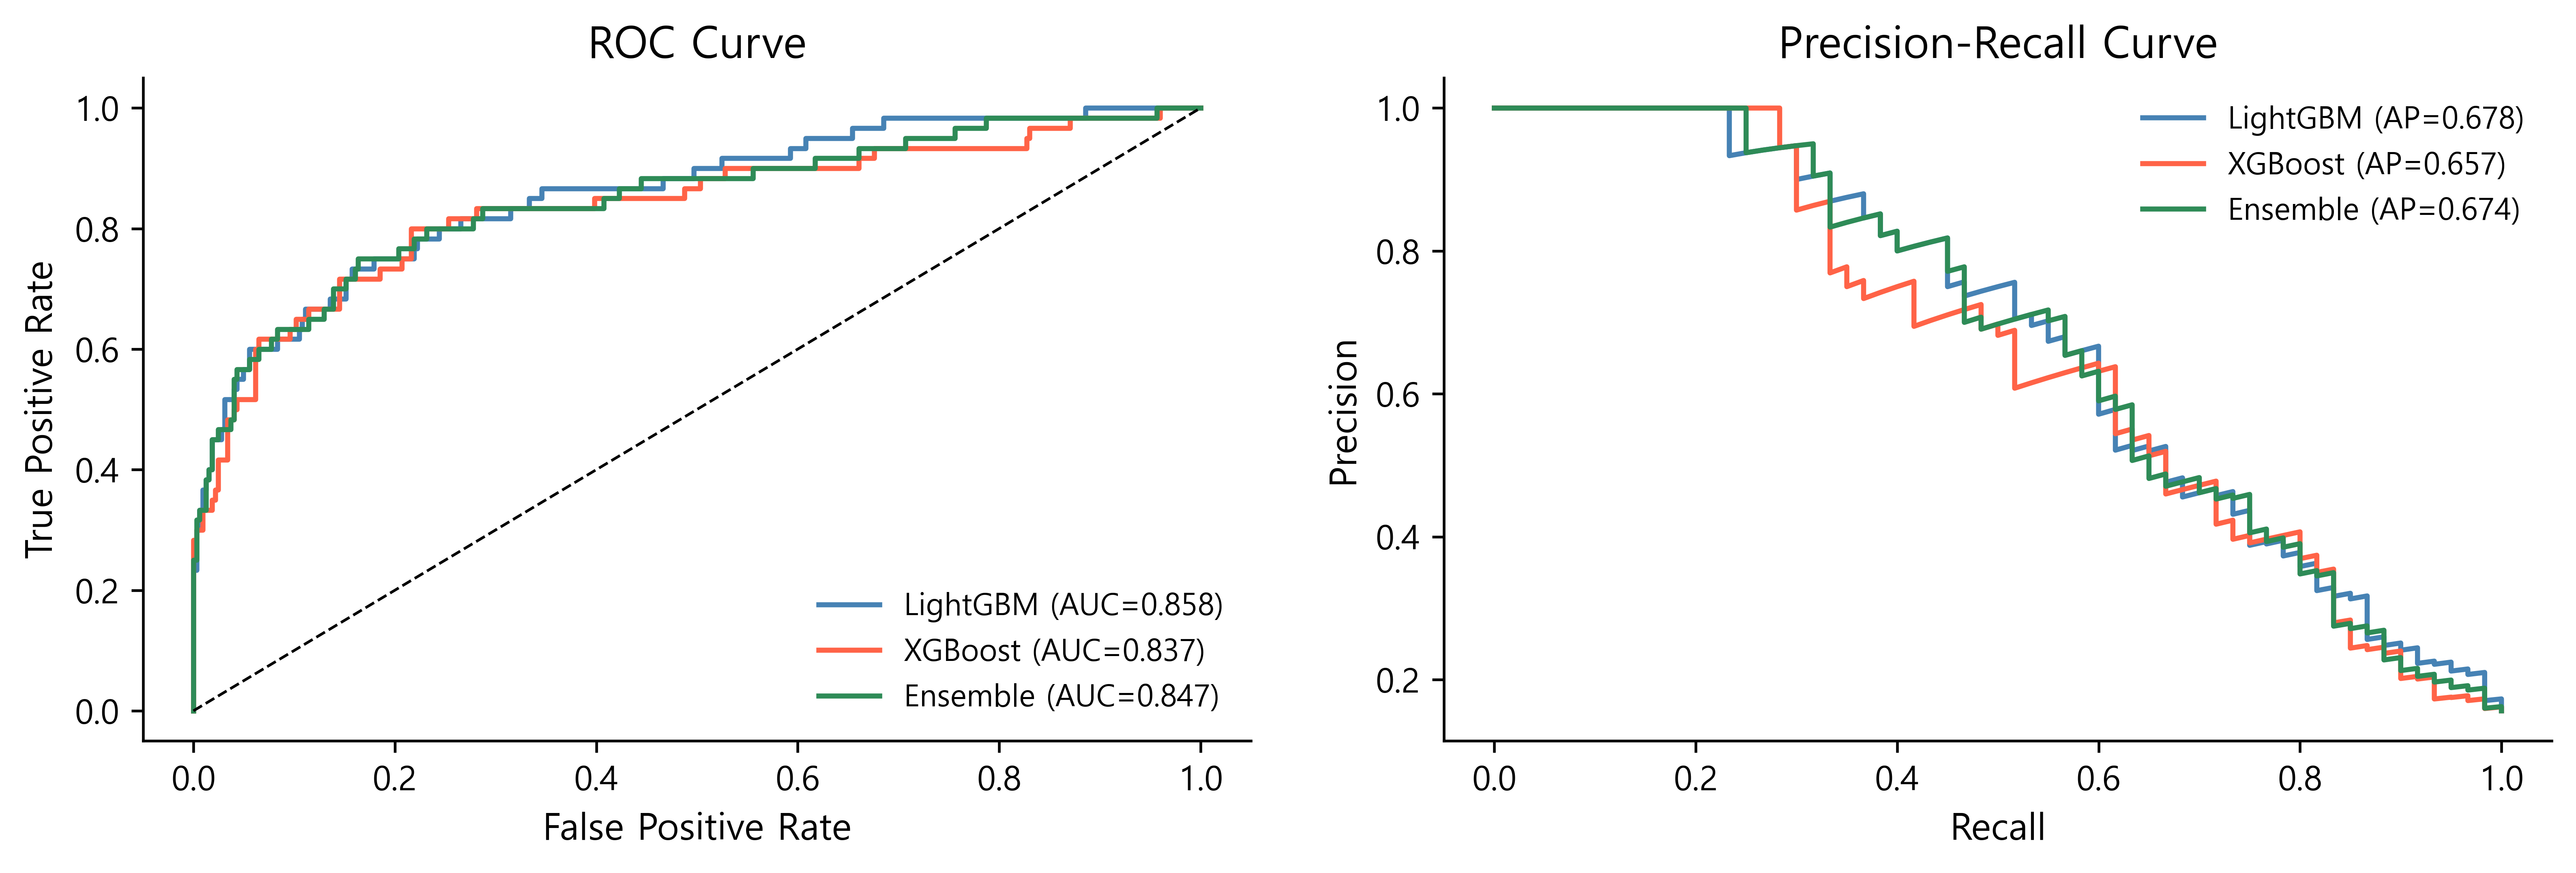

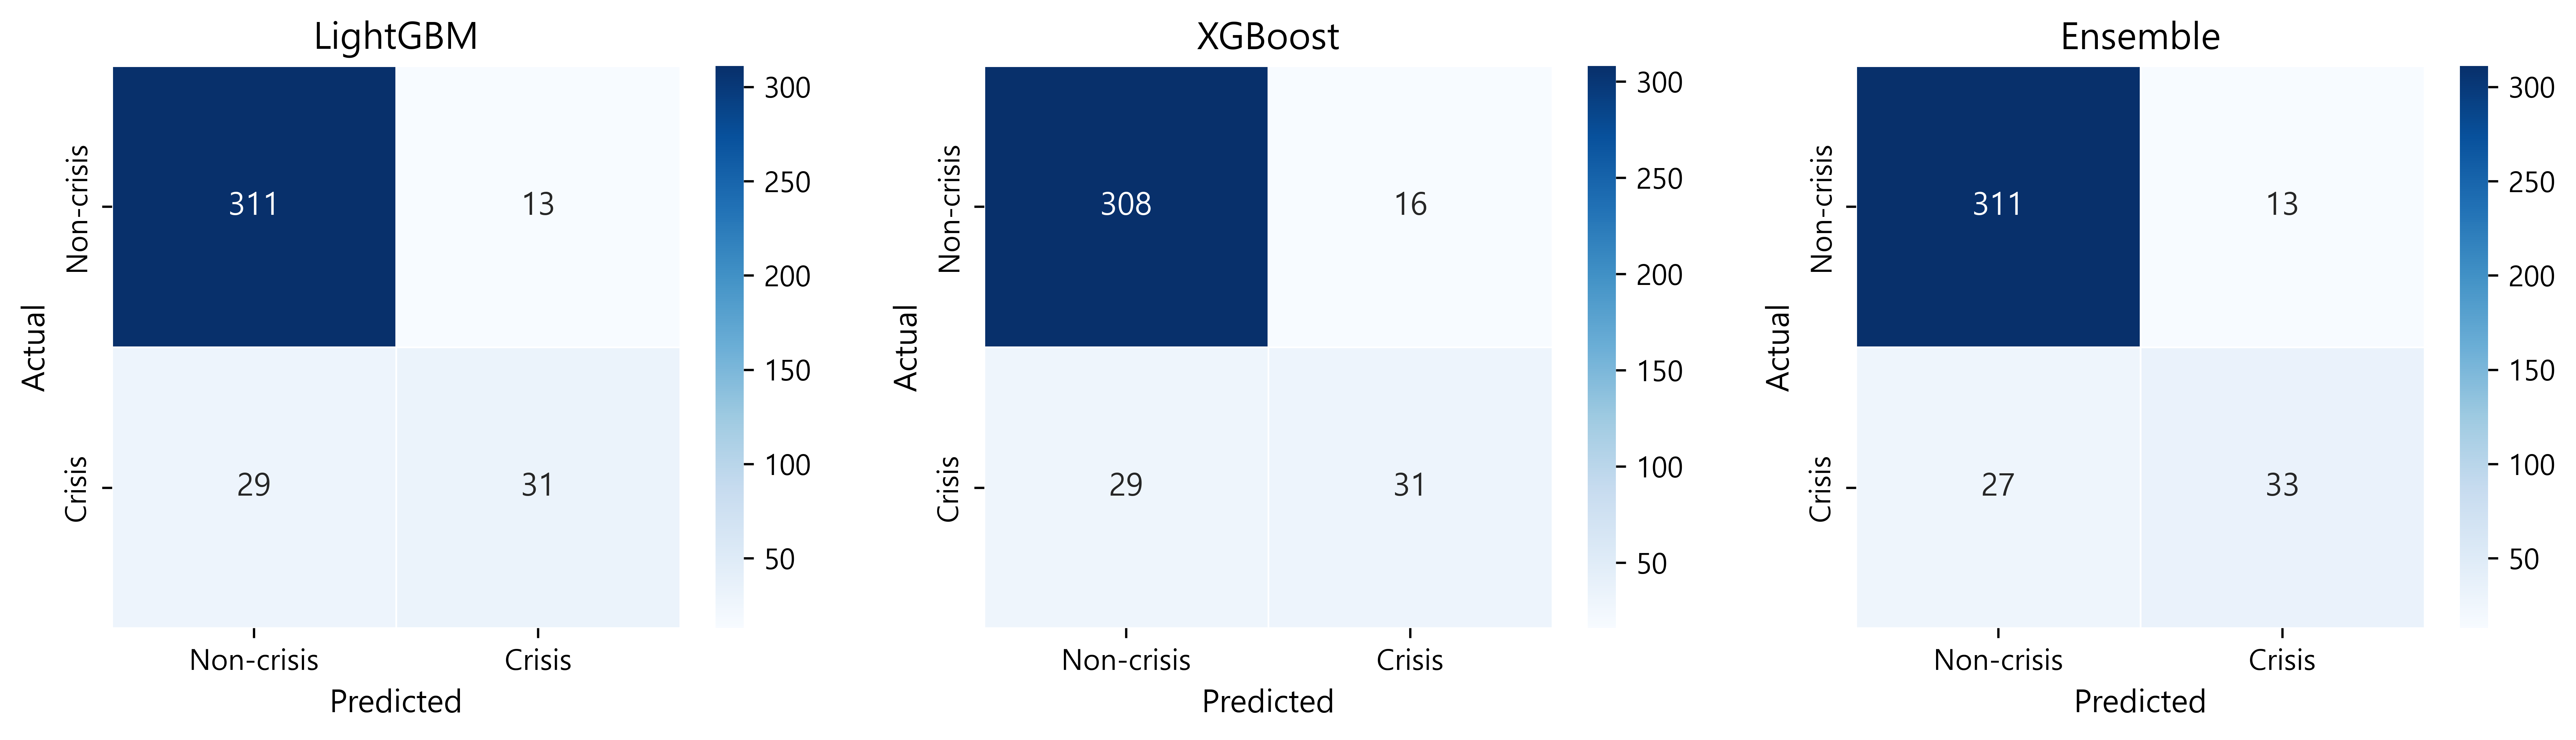

LightGBM CV ROC-AUC: 0.8823 +/- 0.0269
XGBoost CV ROC-AUC: 0.8828 +/- 0.0345
Models saved -> outputs/model_lgbm.pkl, model_xgb.pkl
Test data saved -> data/X_test.csv, y_test.csv


In [3]:
# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load data & define features
# ─────────────────────────────────────────────
df = pd.read_csv("../data/youth_debt_preprocessed.csv")

DROP_COLS = [
    'h19_pid', 'p19_wgc', 'h19_g4',
    'h19_pers_income3', 'h19_pers_income5',
    'h1906_10', 'dsr_raw', 'dsr',
    'annual_debt_service', 'annual_interest', 'annual_repayment',
    'total_income', 'h1909_aq7', 'h1909_aq8', 'h1906_aq2',
]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS + ['debt_crisis']]

X = df[FEATURE_COLS].copy()
y = df['debt_crisis'].copy()

print(f"Features : {len(FEATURE_COLS)}")
print(f"Target   : {y.value_counts().to_dict()}")
print(f"Feature list:\n{FEATURE_COLS}")


# ─────────────────────────────────────────────
# Cell 3 | Impute missing values
# ─────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=FEATURE_COLS)

print("Imputation complete")
print(f"Missing after imputation : {X_imp.isnull().sum().sum()}")


# ─────────────────────────────────────────────
# Cell 4 | Train / test split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}  |  Crisis in train : {y_train.sum()}")
print(f"Test  : {X_test.shape}   |  Crisis in test  : {y_test.sum()}")


# ─────────────────────────────────────────────
# Cell 5 | Apply SMOTE on training set
# ─────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {pd.Series(y_train).value_counts().to_dict()}")
print(f"After  SMOTE : {pd.Series(y_train_sm).value_counts().to_dict()}")


# ─────────────────────────────────────────────
# Cell 6 | Train LightGBM
# ─────────────────────────────────────────────
lgbm = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=10, class_weight='balanced',
    random_state=42, verbose=-1,
)
lgbm.fit(X_train_sm, y_train_sm, eval_set=[(X_test, y_test)], callbacks=[])

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm, target_names=['Non-crisis','Crisis']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_lgbm):.4f}")


# ─────────────────────────────────────────────
# Cell 7 | Train XGBoost
# ─────────────────────────────────────────────
scale_pos = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, random_state=42,
    eval_metric='auc', verbosity=0,
)
xgb.fit(X_train_sm, y_train_sm, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-crisis','Crisis']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_xgb):.4f}")


# ─────────────────────────────────────────────
# Cell 8 | Ensemble (soft voting)
# ─────────────────────────────────────────────
y_prob_ens = (y_prob_lgbm + y_prob_xgb) / 2
y_pred_ens = (y_prob_ens >= 0.5).astype(int)

print("=== Ensemble (LightGBM + XGBoost avg) ===")
print(classification_report(y_test, y_pred_ens, target_names=['Non-crisis','Crisis']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_ens):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_ens):.4f}")


# ─────────────────────────────────────────────
# Cell 9 | ROC & PR curves
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = {'LightGBM': y_prob_lgbm, 'XGBoost': y_prob_xgb, 'Ensemble': y_prob_ens}
colors = ['steelblue', 'tomato', 'seagreen']

for (name, prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=1.5)
axes[0].plot([0,1],[0,1],'k--', lw=0.8)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for (name, prob), color in zip(models.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=1.5)
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/08_roc_pr_curves.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 10 | Confusion matrices
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, pred) in zip(axes, {
    'LightGBM': y_pred_lgbm,
    'XGBoost' : y_pred_xgb,
    'Ensemble': y_pred_ens,
}.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-crisis','Crisis'],
                yticklabels=['Non-crisis','Crisis'],
                linewidths=0.4, linecolor='white',
                annot_kws={'size': 11}, ax=ax)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/09_confusion_matrices.png', **SAVE_KW)
plt.show()


# ─────────────────────────────────────────────
# Cell 11 | Cross-validation (5-fold)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('LightGBM', lgbm), ('XGBoost', xgb)]:
    scores = cross_val_score(model, X_imp, y, cv=cv, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {scores.mean():.4f} +/- {scores.std():.4f}")


# ─────────────────────────────────────────────
# Cell 12 | Save models & data
# ─────────────────────────────────────────────
joblib.dump(lgbm,    '../outputs/model_lgbm.pkl')
joblib.dump(xgb,     '../outputs/model_xgb.pkl')
joblib.dump(imputer, '../outputs/imputer.pkl')

X_test.to_csv('../data/X_test.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
X_train_sm.to_csv('../data/X_train_sm.csv', index=False)
y_train_sm.to_csv('../data/y_train_sm.csv', index=False)
pd.Series(FEATURE_COLS).to_csv('../data/feature_cols.csv', index=False)

print("Models saved -> outputs/model_lgbm.pkl, model_xgb.pkl")
print("Test data saved -> data/X_test.csv, y_test.csv")